# Logistic Regression Model

This notebook demonstrates building a logistic regression model for loan approval prediction using the train.csv dataset. It includes data exploration, model training, evaluation, and visualizations.

In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

## Load and Explore Data

Load the dataset and explore its structure, summary statistics, and basic information.

In [2]:
# Load the data
df = pd.read_csv('train.csv')

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Data info
print("\nData Info:")
print(df.info())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

First 5 rows of the dataset:
   Age  Income_Monthly  Loan_Amount_Requested  Credit_History_Length_Years  \
0   60           52841                1786857                           13   
1   50           85640                 549137                            6   
2   36          180983                 706884                           16   
3   64          153429                 674712                           11   
4   29          178551                1900056                           19   

   Existing_Loans_Count  Past_Defaults  Approved  Employment_Type_Freelancer  \
0                     3              0         0                       False   
1                     2              0         0                       False   
2                     4              0         1                       False   
3                     3              1         1                       False   
4                     3              0         1                       False   

   Employment_Type_Sa

## Data Visualization

Visualize the target variable distribution and correlations between features.

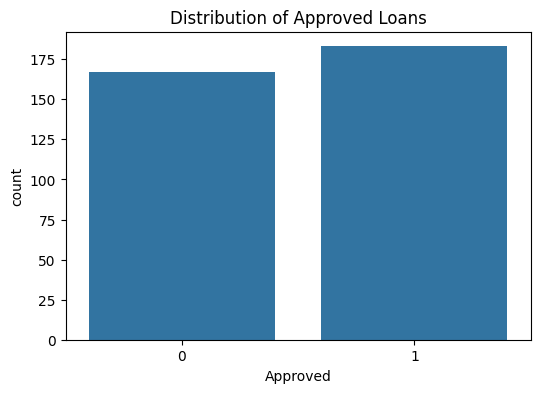

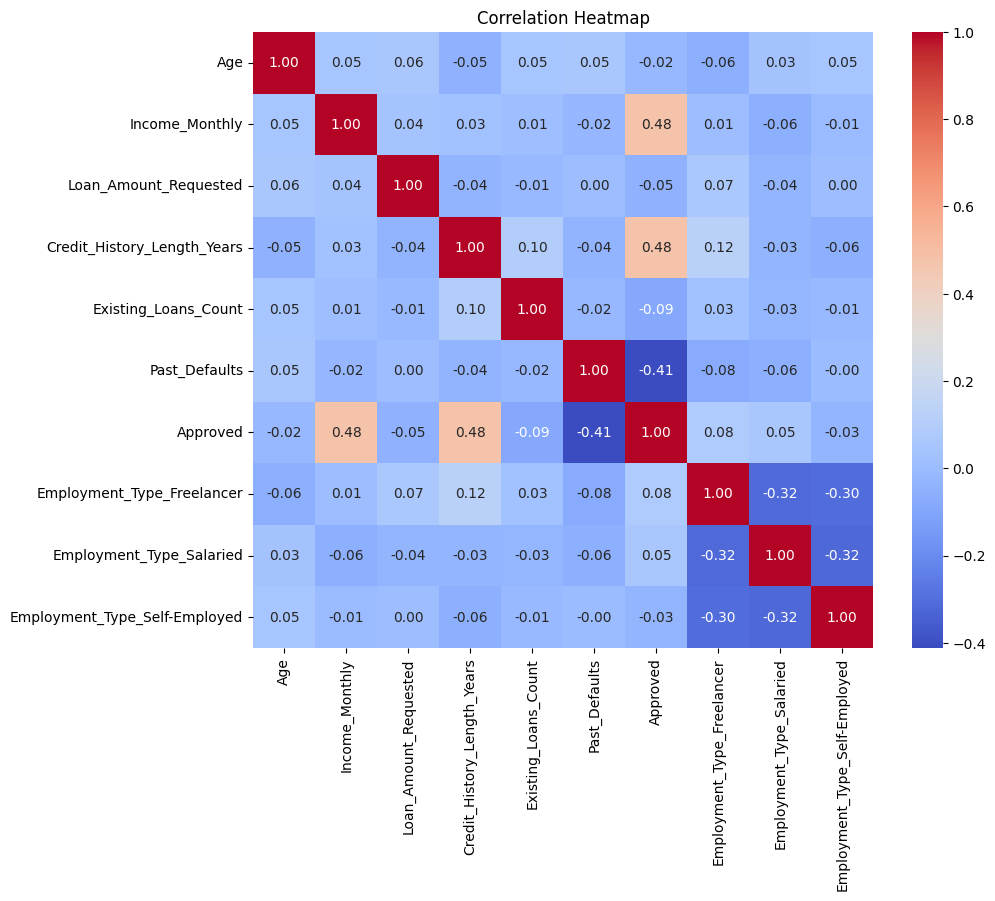

In [3]:
# Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Approved', data=df)
plt.title('Distribution of Approved Loans')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

## Prepare Data

Split the data into features (X) and target (y), then into training and testing sets.

In [4]:
# Features and target
X = df.drop('Approved', axis=1)
y = df['Approved']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Features shape: (350, 9)
Target shape: (350,)
Training set shape: (280, 9)
Testing set shape: (70, 9)


## Train Model

Create and train the logistic regression model.

In [5]:
# Create and train the model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")
print("Model coefficients:")
for feature, coef in zip(X.columns, model.coef_[0]):
    print(f"{feature}: {coef:.4f}")

Model trained successfully!
Model coefficients:
Age: 0.0057
Income_Monthly: 0.0001
Loan_Amount_Requested: -0.0000
Credit_History_Length_Years: 0.4919
Existing_Loans_Count: -0.7602
Past_Defaults: -2.2525
Employment_Type_Freelancer: 0.1128
Employment_Type_Salaried: 0.6087
Employment_Type_Self-Employed: -0.2861


c:\Users\DELL\Desktop\ml\.venv-1\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Evaluate Model

Make predictions and evaluate the model performance.

In [6]:
# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.8571

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.81      0.84        32
           1       0.85      0.89      0.87        38

    accuracy                           0.86        70
   macro avg       0.86      0.85      0.86        70
weighted avg       0.86      0.86      0.86        70



## Confusion Matrix

Visualize the confusion matrix to understand prediction errors.

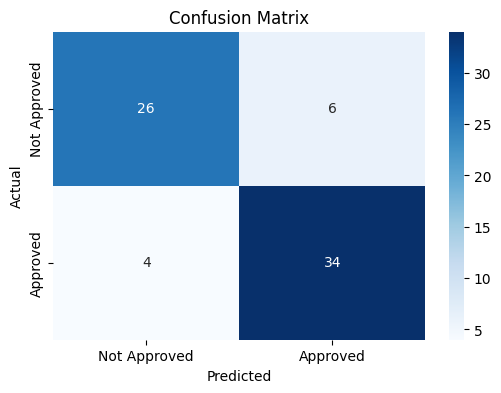

In [7]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Approved', 'Approved'],
            yticklabels=['Not Approved', 'Approved'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## ROC Curve

Plot the Receiver Operating Characteristic (ROC) curve to evaluate model performance.

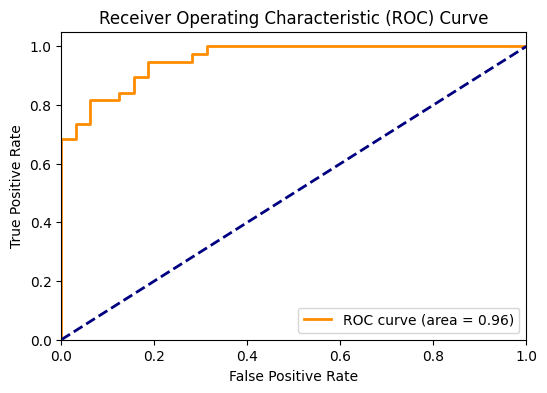

In [8]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

## Feature Importance

Analyze the importance of each feature in the model.

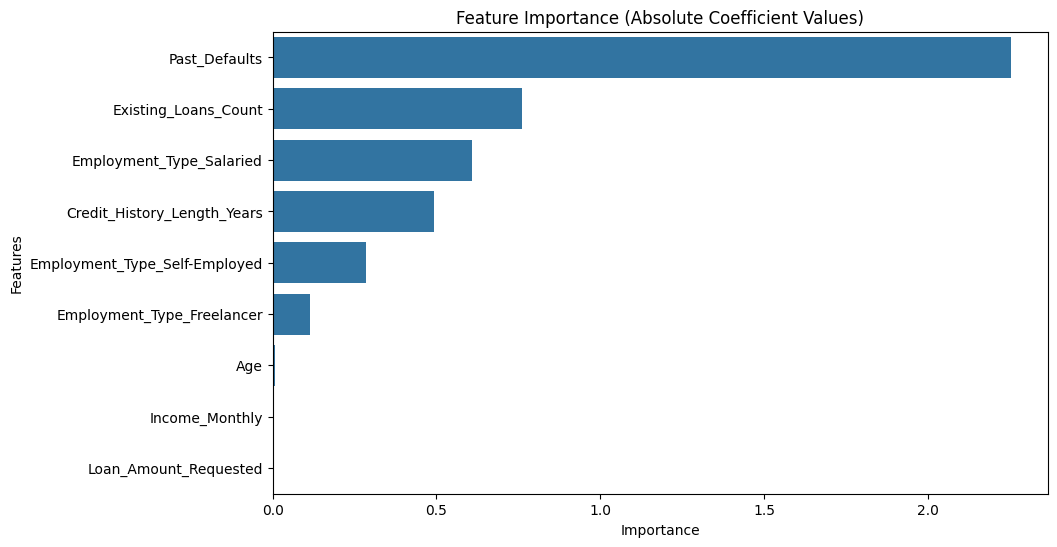

Feature Importance:
                         feature    importance
5                  Past_Defaults  2.252525e+00
4           Existing_Loans_Count  7.601766e-01
7       Employment_Type_Salaried  6.086881e-01
3    Credit_History_Length_Years  4.919130e-01
8  Employment_Type_Self-Employed  2.860517e-01
6     Employment_Type_Freelancer  1.127962e-01
0                            Age  5.687041e-03
1                 Income_Monthly  5.478625e-05
2          Loan_Amount_Requested  8.412189e-08


In [9]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': np.abs(model.coef_[0])
})
feature_importance = feature_importance.sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feature_importance)
plt.title('Feature Importance (Absolute Coefficient Values)')
plt.xlabel('Importance')
plt.ylabel('Features')
plt.show()

print("Feature Importance:")
print(feature_importance)

## Save Model

Save the trained model to a pickle file for future use.

In [10]:
# Save the model
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("Model saved as model.pkl")

Model saved as model.pkl
